# Risco de atraso em pedidos da Olist

## Desafio de negócio

Identificar, **logo após a aprovação do pagamento**, quais pedidos possuem maior risco de serem entregues depois do prazo prometido.

### Objetivos

- estimar futuramente a probabilidade de atraso de cada pedido;
- explicar os principais fatores associados ao risco;
- apoiar uma decisão operacional baseada em custos e capacidade.

> Este notebook não pretende realizar um EDA completo. Ele apresenta uma experiência reduzida e orientada por hipóteses, adequada para uma aula curta.

## Roteiro da experiência

1. Definir o alvo e o instante da previsão.
2. Carregar e verificar as tabelas.
3. Integrar os dados mantendo **uma linha por pedido**.
4. Investigar cinco perguntas orientadas por hipóteses.
5. Registrar conclusões e possíveis features.

**Pergunta central:** quais características disponíveis após a aprovação do pagamento estão associadas ao atraso?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", palette="Blues_r")


ROOT = Path.cwd().parents[0]
DATA_DIR = ROOT / "data" 

DATA_DIR

WindowsPath('c:/Projetos/machine_learning_90h/Olist/data')

## 1. Instante da previsão e risco de data leakage

O modelo deverá gerar a previsão no instante `order_approved_at`. Assim, somente informações já conhecidas até esse momento poderão ser usadas como features.

| Disponível na previsão | Informação futura — não usar como feature |
|---|---|
| data da compra e aprovação | data de envio à transportadora |
| prazo prometido | data real da entrega |
| cliente e localização | avaliação e comentário do cliente |
| itens, vendedores, preço e frete | status ou eventos posteriores |

> A data real da entrega será utilizada apenas para construir o alvo histórico. Ela não poderá entrar como variável explicativa do modelo.

## 2. Carregamento das tabelas

Utilizaremos quatro tabelas obrigatórias. A tabela de produtos será uma extensão opcional.

In [2]:
FILES = {
    "orders": "olist_orders_dataset.csv",
    "items": "olist_order_items_dataset.csv",
    "customers": "olist_customers_dataset.csv",
}

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

orders = pd.read_csv(
    DATA_DIR / "raw" / FILES["orders"],
    parse_dates=date_columns,
)
items = pd.read_csv(DATA_DIR / "raw" / FILES["items"])
customers = pd.read_csv(DATA_DIR / "raw" / FILES["customers"])

print("Pedidos:", orders.shape)
print("Itens:", items.shape)
print("Clientes:", customers.shape)

Pedidos: (99441, 8)
Itens: (112650, 7)
Clientes: (99441, 5)


## 3. Construção do alvo

Para simplificar a experiência, usaremos apenas pedidos com status `delivered` e data real de entrega conhecida.


$$
is\_late = 1 \quad \text{se entrega real > entrega prometida}
$$

> Decisão didática: este recorte permite estudar o atraso observado. Em um projeto real, pedidos cancelados, indisponíveis e ainda abertos exigiriam uma política explícita.

In [3]:
# Seleciona apenas os pedidos que podem ser utilizados para construir
# o histórico de entregas atrasadas e realizadas dentro do prazo.
delivered_orders = orders.loc[
    # Mantém somente pedidos que foram efetivamente entregues.
    orders["order_status"].eq("delivered")

    # Remove pedidos sem a data real em que o cliente recebeu a compra.
    # Essa data é necessária para saber se o pedido atrasou.
    & orders["order_delivered_customer_date"].notna()

    # Remove pedidos sem a data de entrega prometida ao cliente.
    # Sem essa informação, não é possível comparar o previsto com o realizado.
    & orders["order_estimated_delivery_date"].notna()

    # Mantém somente pedidos com a data de aprovação do pagamento.
    # Esse é o momento definido para realizar a previsão.
    & orders["order_approved_at"].notna()
].copy()  # Cria uma cópia independente para evitar alterações no DataFrame original.


# Cria a variável-alvo do problema:
# 1 → pedido entregue depois da data prometida;
# 0 → pedido entregue dentro do prazo ou antes da data prometida.
delivered_orders["is_late"] = (
    delivered_orders["order_delivered_customer_date"]
    > delivered_orders["order_estimated_delivery_date"]
).astype("int8")  # Armazena 0 e 1 usando um tipo inteiro que ocupa menos memória.


# Apresenta a quantidade total de pedidos antes da aplicação dos filtros.
print(f"Pedidos originais: {len(orders):,}")


# Apresenta quantos pedidos permaneceram no recorte histórico.
print(f"Pedidos no recorte histórico: {len(delivered_orders):,}")


# Mostra a quantidade de pedidos em cada classe:
# 0 = entregue no prazo;
# 1 = entregue com atraso.
display(
    delivered_orders["is_late"].value_counts(dropna=False)
)

Pedidos originais: 99,441
Pedidos no recorte histórico: 96,456


is_late
0    88630
1     7826
Name: count, dtype: int64

## 4. Integração no nível do pedido

A tabela de itens tem várias linhas para o mesmo pedido. Antes do `merge`, precisamos agregá-la. Caso contrário, a unidade de análise deixaria de ser o pedido e alguns pedidos teriam peso maior simplesmente por possuírem mais itens.

In [4]:
# A tabela de itens possui uma linha para cada item presente no pedido.
# Portanto, um mesmo order_id pode aparecer várias vezes.
#
# Como o objetivo é construir uma base com uma linha por pedido,
# precisamos agrupar os itens antes de integrar essa tabela às demais.
items_agg = (
    items.groupby(
        "order_id",       # Agrupa todos os itens pertencentes ao mesmo pedido.
        as_index=False,   # Mantém order_id como uma coluna comum.
    )
    .agg(
        # Conta quantas linhas de itens existem em cada pedido.
        # Um pedido com três produtos registrados terá item_count igual a 3.
        item_count=("order_item_id", "count"),

        # Conta quantos vendedores diferentes participam do pedido.
        # O nunique evita contar o mesmo vendedor mais de uma vez.
        seller_count=("seller_id", "nunique"),

        # Soma os preços dos itens para obter o valor total dos produtos
        # presentes no pedido.
        total_price=("price", "sum"),

        # Soma o frete de todos os itens para obter o valor total de frete
        # associado ao pedido.
        total_freight=("freight_value", "sum"),
    )
)


# Verifica se cada pedido aparece somente uma vez após a agregação.
#
# Se a condição for falsa, o Python interromperá a execução e lançará
# um AssertionError. Essa checagem ajuda a garantir que a unidade de
# análise da nova tabela é realmente o pedido.
assert items_agg["order_id"].is_unique


# Exibe as cinco primeiras linhas da tabela agregada.
items_agg.head()

,order_id,item_count,seller_count,total_price,total_freight
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,199.90,18.14


In [8]:
# Começa com os pedidos entregues que possuem as datas necessárias
# para determinar se houve atraso.
orders_analysis = (
    delivered_orders

    # Adiciona as informações agregadas dos itens:
    # quantidade de itens, vendedores, preço total e frete total.
    .merge(
        items_agg,
        on="order_id",            # Coluna usada para relacionar as tabelas.
        how="left",               # Mantém todos os pedidos de delivered_orders.
        validate="one_to_one",    # Verifica se order_id é único nas duas tabelas.
    )

    # Adiciona a localização do cliente.
    .merge(
        customers[
            [
                "customer_id",
                "customer_state",
                "customer_city",
            ]
        ],
        on="customer_id",         # Relaciona cada pedido ao seu cliente.
        how="left",               # Mantém todos os pedidos da base anterior.
        validate="many_to_one",   # Vários pedidos podem apontar para um cliente.
    )
)

assert orders_analysis["order_id"].is_unique, "A base final deve manter uma linha por pedido."
assert len(orders_analysis) == len(delivered_orders), "A integração alterou o total de pedidos."

print("Dimensão da base analítica:", orders_analysis.shape)
orders_analysis.head()

Dimensão da base analítica: (96456, 15)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_late,item_count,seller_count,total_price,total_freight,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0,1,1,29.99,8.72,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,0,1,1,118.70,22.76,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0,1,1,159.90,19.22,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0,1,1,45.00,27.20,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0,1,1,19.90,8.72,SP,santo andre


## 5. Engenharia mínima para o EDA

Estas variáveis são construídas apenas com dados conhecidos até a aprovação do pagamento.

In [9]:
# Calcula quantos dias a empresa prometeu para realizar a entrega,
# considerando como início o momento da aprovação do pagamento.
orders_analysis["promised_days"] = (
    orders_analysis["order_estimated_delivery_date"]  # Data prometida para a entrega.
    - orders_analysis["order_approved_at"]            # Data de aprovação do pagamento.
).dt.total_seconds().div(86_400)          # Converte segundos para dias.


# Extrai o número do mês em que a compra foi realizada.
# Exemplo: janeiro = 1, fevereiro = 2, ..., dezembro = 12.
orders_analysis["purchase_month"] = (
    orders_analysis["order_purchase_timestamp"].dt.month
)


# Extrai o dia da semana em que a compra foi realizada.
#
# O Pandas representa os dias da seguinte forma:
# 0 = segunda-feira
# 1 = terça-feira
# 2 = quarta-feira
# 3 = quinta-feira
# 4 = sexta-feira
# 5 = sábado
# 6 = domingo
orders_analysis["purchase_weekday"] = (
    orders_analysis["order_purchase_timestamp"].dt.dayofweek
)


# Extrai a hora em que a compra foi realizada.
# Os valores variam de 0 a 23.
#
# Exemplo:
# 0  = meia-noite
# 8  = 8 horas
# 14 = 14 horas
# 23 = 23 horas
orders_analysis["purchase_hour"] = (
    orders_analysis["order_purchase_timestamp"].dt.hour
)


# Gera estatísticas descritivas para o prazo prometido:
# quantidade, média, desvio-padrão, mínimo, quartis e máximo.
#
# describe() gera as estatísticas.
# to_frame() transforma o resultado em DataFrame.
# .T transpõe a tabela para que as estatísticas apareçam como colunas.
display(
    orders_analysis["promised_days"]
    .describe()
    .to_frame()
    .T
)


# Conta quantos pedidos apresentam prazo prometido menor ou igual a zero.
#
# Esses casos seriam suspeitos porque significariam que a data prometida
# ocorreu antes ou exatamente no momento da aprovação do pagamento.
print(
    "Prazos não positivos:",
    orders_analysis["promised_days"].le(0).sum()
)

,count,mean,std,min,25%,50%,75%,max
promised_days,96456.0,23.306482,8.765103,-6.664225,17.905885,22.668762,28.066727,153.57603


Prazos não positivos: 6


# Pergunta 1: Qual é a frequência de pedidos atrasados?

**Hipótese:** os atrasos são minoritários, produzindo desbalanceamento entre as classes.

**Discussão:** se um modelo sempre previsse “não atrasará”, qual seria sua acurácia? Ela seria suficiente para avaliar o modelo?

,pedidos,percentual
is_late,,
No prazo,88630,91.89
Atrasado,7826,8.11


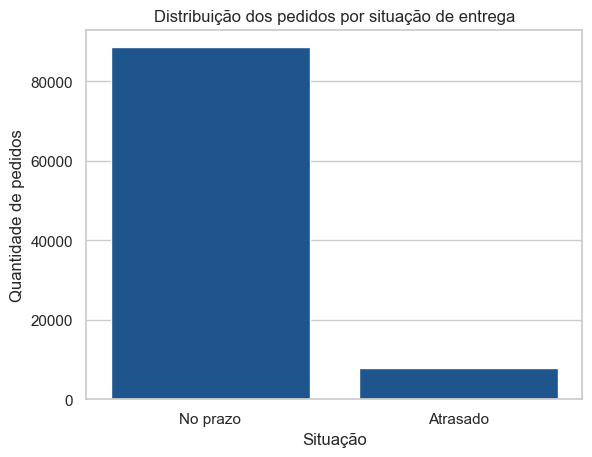

In [10]:
# Analisa a distribuição da variável alvo (is_late),
# que indica se o pedido foi entregue no prazo ou com atraso.
target_summary = (

    # Seleciona somente a coluna que representa a variável alvo.
    orders_analysis["is_late"]

    # Substitui os valores numéricos por rótulos mais fáceis de interpretar:
    # 0 = pedido entregue no prazo
    # 1 = pedido entregue com atraso
    .map({0: "No prazo", 1: "Atrasado"})

    # Conta quantos pedidos existem em cada categoria.
    .value_counts()

    # Converte o resultado de Series para DataFrame
    # e dá o nome "pedidos" à coluna com as contagens.
    .to_frame("pedidos")
)


# Calcula o percentual de pedidos de cada categoria.
target_summary["percentual"] = (

    # Divide a quantidade de pedidos da categoria
    # pelo total de pedidos da base e multiplica por 100.
    target_summary["pedidos"] / target_summary["pedidos"].sum() * 100

# Arredonda o percentual para duas casas decimais.
).round(2)


# Exibe a tabela com quantidade e percentual
# de pedidos "No prazo" e "Atrasado".
display(target_summary)


# Cria um DataFrame auxiliar apenas para a visualização.
# A coluna original is_late é mantida e uma nova coluna
# chamada "situacao" é adicionada com rótulos mais legíveis.
eda_plot = orders_analysis.assign(

    situacao=orders_analysis["is_late"].map(
        {0: "No prazo", 1: "Atrasado"}
    )

)


# Cria um gráfico de barras mostrando quantos pedidos
# existem em cada situação de entrega.
ax = sns.countplot(

    # DataFrame utilizado para construir o gráfico.
    data=eda_plot,

    # Coluna que será representada no eixo X.
    x="situacao",

    # Define explicitamente a ordem em que
    # as categorias aparecerão no gráfico.
    order=["No prazo", "Atrasado"],

)


# Define os textos apresentados no gráfico.
ax.set(

    # Nome do eixo X.
    xlabel="Situação",

    # Nome do eixo Y.
    ylabel="Quantidade de pedidos",

    # Título do gráfico.
    title="Distribuição dos pedidos por situação de entrega",

)


# Exibe o gráfico.
plt.show()

**Conclusão da pergunta 1:** escreva aqui o que os dados mostraram.

- Taxa de atraso: `8,11%`
- A hipótese foi apoiada? `Sim`
- Implicação para a modelagem: `a acurácia isoladamente não será suficiente para avaliar o modelo, pois ele poderá favorecer a classe majoritária.`

# Pergunta 2: Pedidos com prazos menores atrasam mais?

**Hipótese:** quando a empresa promete entregar em poucos dias, existe menos
margem para problemas logísticos e o pedido pode apresentar maior risco de atraso.

> verificaremos apenas se existe uma relação nos dados. O resultado
não será suficiente para afirmar que o tamanho do prazo é a causa do atraso.

,promised_days_group,pedidos,taxa_atraso
0,Até 7,1637,28.34
1,8–14,11531,6.76
2,15–21,25185,9.07
3,22–30,39681,8.32
4,Mais de 30,18416,5.38


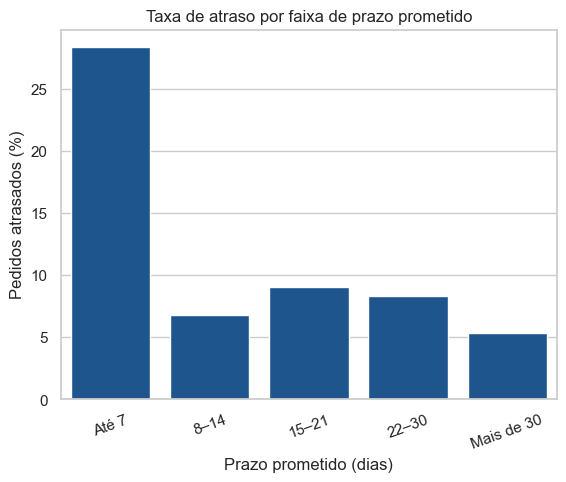

In [11]:
# Seleciona apenas os pedidos cujo prazo prometido é maior que zero.
# Prazos iguais ou menores que zero podem indicar inconsistência nas datas.
valid_deadline = orders_analysis.loc[
    orders_analysis["promised_days"].gt(0)
].copy()


# Transforma a quantidade de dias prometidos em faixas.
# Isso facilita a comparação da taxa de atraso entre prazos
# mais curtos e prazos mais longos.
valid_deadline["promised_days_group"] = pd.cut(
    valid_deadline["promised_days"],

    # Define os limites das faixas:
    # (0, 7], (7, 14], (14, 21], (21, 30] e acima de 30.
    bins=[0, 7, 14, 21, 30, np.inf],

    # Define os nomes que serão exibidos para cada faixa.
    labels=[
        "Até 7",
        "8–14",
        "15–21",
        "22–30",
        "Mais de 30",
    ],
)


# Agrupa os pedidos de acordo com a faixa de prazo prometido.
deadline_risk = (
    valid_deadline
    .groupby(
        "promised_days_group",

        # Mostra somente as faixas que possuem pedidos.
        observed=True,
    )
    .agg(
        # Conta quantos pedidos existem em cada faixa.
        pedidos=("order_id", "size"),

        # Calcula a média da variável is_late em cada faixa.
        #
        # Como:
        # 0 = pedido no prazo
        # 1 = pedido atrasado
        #
        # A média corresponde à proporção de pedidos atrasados.
        taxa_atraso=("is_late", "mean"),
    )

    # Transforma a faixa de prazo, que virou índice depois
    # do groupby, novamente em uma coluna.
    .reset_index()
)


# Converte a taxa de atraso de proporção para percentual.
# Exemplo: 0.0811 passa a ser 8.11.
deadline_risk["taxa_atraso"] *= 100


# Exibe a tabela com duas casas decimais.
display(
    deadline_risk.round(2)
)


# Cria um gráfico de barras:
# eixo X = faixas de prazo prometido;
# eixo Y = percentual de pedidos atrasados.
ax = sns.barplot(
    data=deadline_risk,
    x="promised_days_group",
    y="taxa_atraso",
)


# Define os nomes dos eixos.
ax.set(
    xlabel="Prazo prometido (dias)",
    ylabel="Pedidos atrasados (%)",
)


# Define o título principal do gráfico.
ax.set_title(
    "Taxa de atraso por faixa de prazo prometido"
)


# Inclina os textos do eixo X em 20 graus
# para facilitar a leitura dos nomes das faixas.
plt.xticks(rotation=20)


# Exibe o gráfico.
plt.show()

**Conclusão da pergunta 2:** a taxa muda de forma consistente entre as faixas? Há faixas com poucas observações?

Os pedidos com prazo prometido de até 7 dias apresentaram uma taxa de atraso
muito superior às demais faixas, próxima de 28%. Nas outras faixas, a taxa
variou aproximadamente entre 5% e 9%.

A hipótese foi parcialmente apoiada: prazos muito curtos estão associados a
maior risco de atraso, mas a taxa não diminui de forma perfeitamente consistente
conforme o prazo aumenta.

Somente pelo gráfico não é possível afirmar se há faixas com poucas observações,
pois ele apresenta a taxa de atraso, mas não a quantidade de pedidos. Para essa
avaliação, também é necessário observar a coluna `pedidos` da tabela
`deadline_risk`.

# Pergunta 3: Pedidos maiores ou mais complexos atrasam mais?

**Hipótese:** pedidos com mais itens ou vendedores apresentam maior complexidade logística e maior risco.

In [12]:
complexity_summary = (
    orders_analysis.groupby("is_late")[["item_count", "seller_count", "total_price", "total_freight"]]
    .median()
    .rename(index={0: "No prazo", 1: "Atrasado"})
)
display(complexity_summary.round(2))


,item_count,seller_count,total_price,total_freight
is_late,,,,
No prazo,1.0,1.0,85.5,17.07
Atrasado,1.0,1.0,89.9,18.06


,seller_group,pedidos,taxa_atraso
0,Mais de um,1275,1.41
1,Um vendedor,95181,8.20


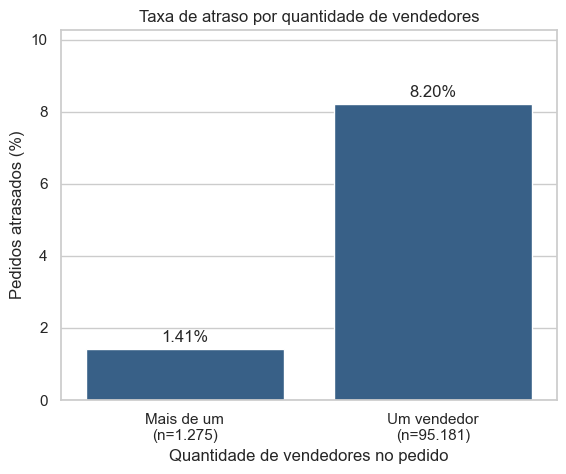

In [13]:
# Outra forma de investigar:
# comparar a taxa de atraso pela quantidade de vendedores no pedido.
complexity_risk = (
    orders_analysis

    # Cria uma coluna temporária para separar os pedidos em dois grupos:
    # "Um vendedor" ou "Mais de um".
    .assign(
        seller_group=np.where(
            orders_analysis["seller_count"].gt(1),
            "Mais de um",
            "Um vendedor",
        )
    )

    # Agrupa os pedidos pela quantidade de vendedores.
    .groupby("seller_group")

    # Calcula a quantidade de pedidos e a proporção de atrasos de cada grupo.
    .agg(
        pedidos=("order_id", "size"),
        taxa_atraso=("is_late", "mean"),
    )

    # Transforma seller_group, que estava no índice, em uma coluna comum.
    .reset_index()
)


# Converte a taxa de atraso de proporção para percentual.
complexity_risk["taxa_atraso"] *= 100


# Exibe a tabela com os resultados arredondados.
display(
    complexity_risk.round(2)
)


# Cria um rótulo contendo o nome do grupo e a quantidade de pedidos.
#
# Exemplo:
# Um vendedor
# (n=95.181)
complexity_risk["grupo_label"] = (
    complexity_risk["seller_group"]
    + "\n(n="
    + complexity_risk["pedidos"].map(
        lambda valor: f"{valor:,}".replace(",", ".")
    )
    + ")"
)


# Cria o gráfico de barras com a taxa de atraso de cada grupo.
ax = sns.barplot(
    data=complexity_risk,
    x="grupo_label",
    y="taxa_atraso",
    color="#2B6094",
)


# Escreve o percentual de atraso acima de cada barra.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3,
    )


# Personaliza os títulos do gráfico e dos eixos.
ax.set(
    xlabel="Quantidade de vendedores no pedido",
    ylabel="Pedidos atrasados (%)",
    title="Taxa de atraso por quantidade de vendedores",
)


# Define o limite do eixo vertical.
# A margem de 25% evita que os valores escritos acima das barras
# fiquem encostados no limite superior do gráfico.
ax.set_ylim(
    0,
    complexity_risk["taxa_atraso"].max() * 1.25,
)


# Exibe o gráfico.
plt.show()

**Conclusão da pergunta 3:** diferenças nas medianas parecem operacionalmente relevantes? Os boxplots mostram muita sobreposição?

A hipótese não foi apoiada em relação à quantidade de vendedores. Os pedidos
com apenas um vendedor apresentaram taxa de atraso de 8,20%, enquanto os pedidos
com mais de um vendedor apresentaram taxa de 1,41%.

Esse resultado contraria a expectativa inicial de que vários vendedores
aumentariam a complexidade logística e o risco de atraso.

# Pergunta 4: O risco varia geograficamente?

**Hipótese:** alguns estados apresentam maior risco devido à distância ou à infraestrutura logística.

Para evitar conclusões instáveis, mostraremos apenas estados com pelo menos 100 pedidos no recorte.

,customer_state,pedidos,taxa_atraso
0,AL,397,23.93
1,MA,716,19.69
2,PI,476,15.97
3,CE,1278,15.34
4,SE,335,15.22
5,BA,3256,14.04
6,RJ,12348,13.48
7,TO,274,12.77
8,PA,946,12.37
9,ES,1995,12.23


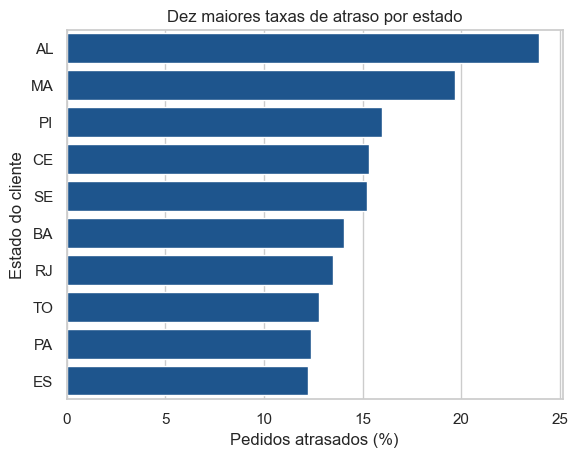

In [14]:
# Analisa o risco de atraso de acordo com o estado do cliente.
state_risk = (

    # Agrupa os pedidos pelo estado do cliente.
    orders_analysis.groupby("customer_state")

    # Para cada estado, calcula:
    # - pedidos: quantidade total de pedidos;
    # - taxa_atraso: proporção de pedidos que atrasaram.
    #
    # Como is_late possui 0 = No prazo e 1 = Atrasado,
    # a média dessa coluna corresponde diretamente à proporção de atrasos.
    .agg(
        pedidos=("order_id", "size"),
        taxa_atraso=("is_late", "mean")
    )

    # Mantém apenas estados com pelo menos 100 pedidos.
    # Esse filtro evita analisar taxas calculadas a partir
    # de uma quantidade muito pequena de observações.
    .query("pedidos >= 100")

    # Ordena os estados da maior para a menor taxa de atraso.
    .sort_values("taxa_atraso", ascending=False)

    # Retira customer_state do índice e transforma
    # novamente em uma coluna do DataFrame.
    .reset_index()
)


# A taxa de atraso inicialmente está representada como proporção
# (por exemplo, 0.15). Multiplicamos por 100 para transformá-la
# em percentual (15%).
state_risk["taxa_atraso"] *= 100


# Exibe os 10 estados com as maiores taxas de atraso,
# arredondando os valores numéricos para duas casas decimais.
display(state_risk.head(10).round(2))


# Cria um gráfico de barras com os 10 estados
# que apresentam as maiores taxas de atraso.
ax = sns.barplot(
    data=state_risk.head(10),
    x="taxa_atraso",
    y="customer_state"
)


# Define os nomes dos eixos.
ax.set(
    xlabel="Pedidos atrasados (%)",
    ylabel="Estado do cliente"
)


# Define o título do gráfico.
ax.set_title("Dez maiores taxas de atraso por estado")


# Exibe o gráfico.
plt.show()

**Conclusão da pergunta 4:** localização pode ser útil, mas “estado” talvez esteja representando outros fatores não observados. Que fatores seriam esses?

A hipótese foi apoiada. A taxa de atraso varia entre os estados analisados.
Alagoas apresentou a maior taxa, com 23,93%, seguido por Maranhão, com 19,69%.
Esses valores são consideravelmente superiores à taxa geral de atraso da base,
que foi de 8,11%.

Isso indica que a localização do cliente pode ser uma variável útil para a
previsão. Entretanto, não podemos concluir que o estado, por si só, causa o
atraso. O estado pode estar representando outros fatores logísticos não
observados diretamente na análise.

# Pergunta 5: O momento da compra está associado ao atraso?

**Hipótese:** determinados meses enfrentam maior pressão logística e apresentam maior taxa de atraso.

,purchase_month,pedidos,taxa_atraso
0,1,7817,6.23
1,2,8196,13.43
2,3,9549,17.15
3,4,9101,5.96
4,5,10294,6.64
5,6,9231,2.21
6,7,10028,4.08
7,8,10544,7.58
8,9,4151,5.23
9,10,4743,5.06


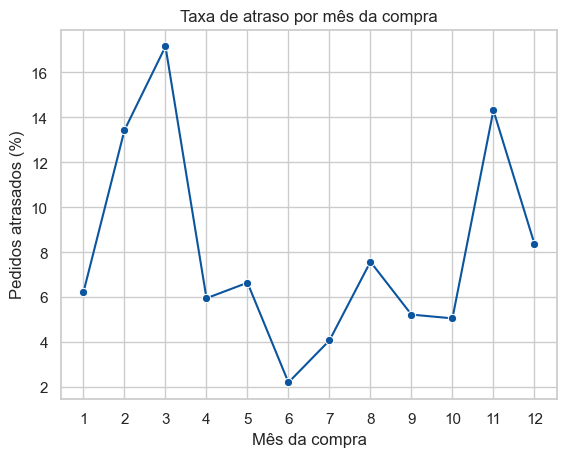

In [15]:
# Analisa se o risco de atraso varia de acordo com o mês da compra.
monthly_risk = (

    # Agrupa os pedidos pelo mês em que a compra foi realizada.
    orders_analysis.groupby("purchase_month")

    # Para cada mês, calcula:
    # - pedidos: quantidade total de pedidos realizados;
    # - taxa_atraso: proporção de pedidos que atrasaram.
    #
    # Como is_late contém 0 = No prazo e 1 = Atrasado,
    # a média dessa coluna representa diretamente a proporção de atrasos.
    .agg(
        pedidos=("order_id", "size"),
        taxa_atraso=("is_late", "mean")
    )

    # Transforma purchase_month, que estava no índice após o groupby,
    # novamente em uma coluna do DataFrame.
    .reset_index()
)


# Converte a taxa de atraso de proporção para percentual.
# Por exemplo: 0.12 passa a representar 12%.
monthly_risk["taxa_atraso"] *= 100


# Exibe a tabela com a quantidade de pedidos e
# a taxa de atraso de cada mês, com duas casas decimais.
display(monthly_risk.round(2))


# Cria um gráfico de linha para observar como a taxa de atraso
# varia ao longo dos meses do ano.
ax = sns.lineplot(
    data=monthly_risk,
    x="purchase_month",
    y="taxa_atraso",

    # Adiciona um ponto em cada mês para facilitar
    # a identificação dos valores observados.
    marker="o"
)


# Configura os eixos do gráfico.
ax.set(

    # Garante que o eixo X apresente os meses de 1 a 12.
    xticks=range(1, 13),

    xlabel="Mês da compra",
    ylabel="Pedidos atrasados (%)"
)


# Define o título do gráfico.
ax.set_title("Taxa de atraso por mês da compra")


# Exibe o gráfico.
plt.show()

**Conclusão da pergunta 5:** há indícios de sazonalidade? Compare também a quantidade de pedidos por mês antes de concluir.

> Existem indícios de variação temporal na taxa de atraso. Março e novembro
apresentaram taxas consideravelmente maiores, enquanto junho apresentou a menor
taxa.

Entretanto, ainda não podemos confirmar a existência de sazonalidade. A análise
agrupa meses de anos diferentes e a quantidade de pedidos pode variar entre os
meses. Meses com poucas observações podem apresentar taxas menos estáveis.

Para confirmar um padrão sazonal, seria necessário analisar ano e mês
separadamente e verificar se o comportamento se repete em diferentes anos..